###1. Uraikan secara rinci masalah apa yang dihadapi Bank Sentral berdasarkan informasi awal di atas. Mengapa harus dilakukan predictive analytic dalam masalah ini? Bagaimanakah project ini akan berkontribusi pada pemecahan masalah pada institusi ini?

### 6. Sebutkan 5 variable yang paling mempengaruhi kebangkrutan sebuah bank.

## jawaban no 1 dan 6 ada di word
### https://docs.google.com/document/d/1ktV9acepjFpOaVECYwWSz2S_JN6srgf1S_IPud2oNxQ/edit?usp=sharing

###2. Data Understanding, jabarkan apa yang menjadi target variable? Buatkan visualisasi tahapan Exploratory Data Analysis untuk melihat beberapa hubungan 2 variable dengan target variable.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [83]:
# LOAFDING DATA
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data-bank.csv")

# TAMPILKAN 5 DATA TERATAS
print(" 5 DATA TERATAS")
display(df.head())

print("\n INFO DATA")
df.info()

print("\n DESKRIPSI NUMERIK")
display(df.describe())


 5 DATA TERATAS


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490



 INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


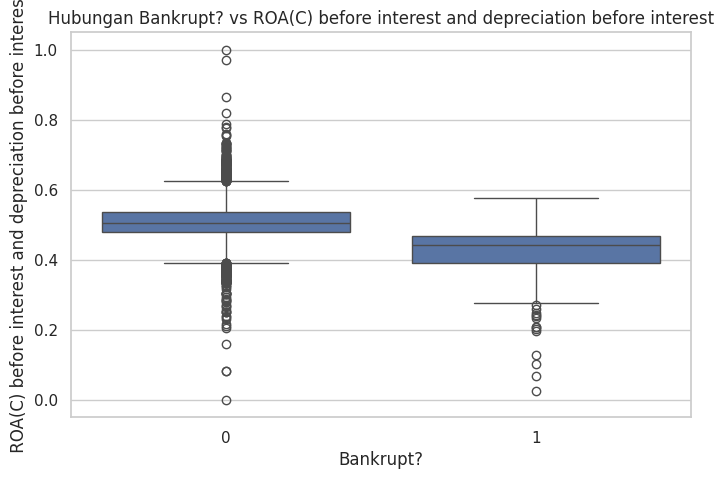

In [84]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Bankrupt?', y=' ROA(C) before interest and depreciation before interest')
plt.title("Hubungan Bankrupt? vs ROA(C) before interest and depreciation before interest")
plt.show()

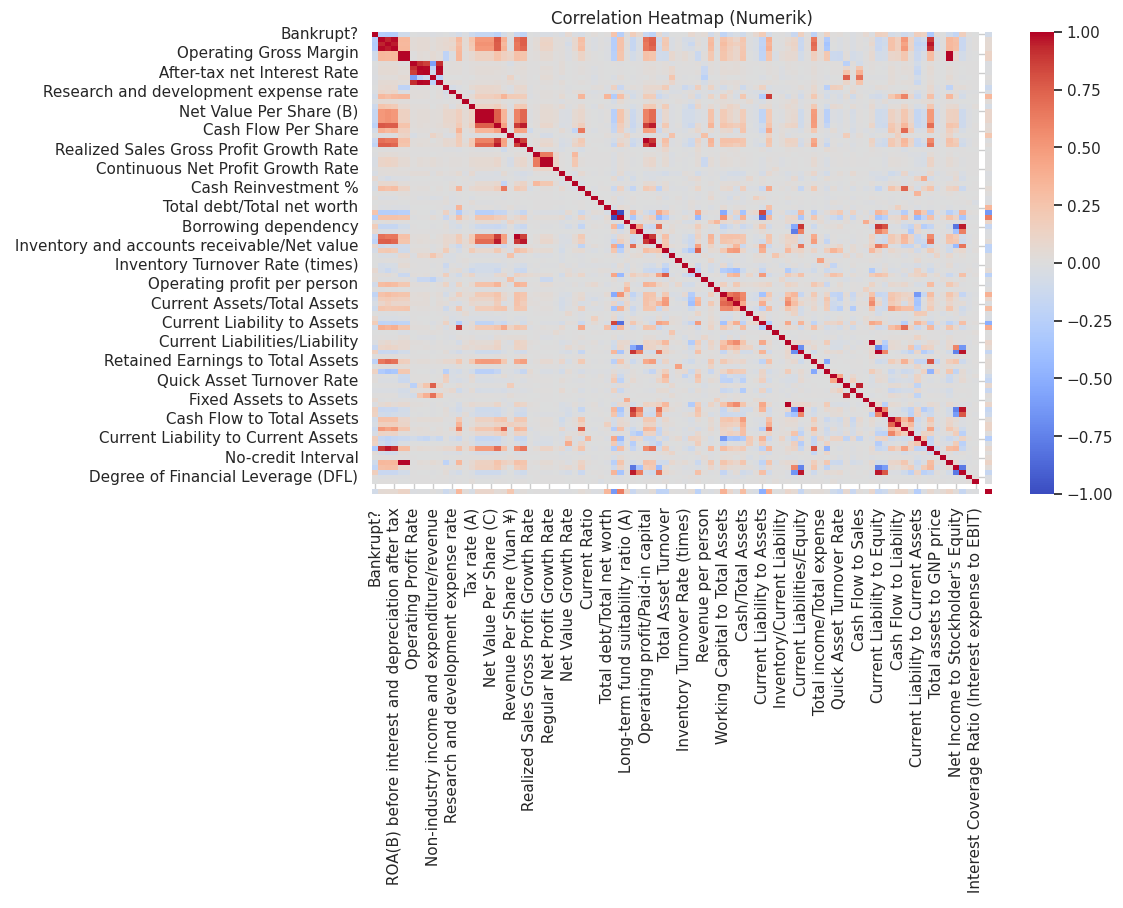

In [85]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerik)")
plt.show()


### 3. Data Preparation, Apakah data ini “Balance”? dan jika tidak, bagaimana cara untuk menangani data yang tidak balance? Buatkan juga tahapan data cleaning dan data transformation nya.

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


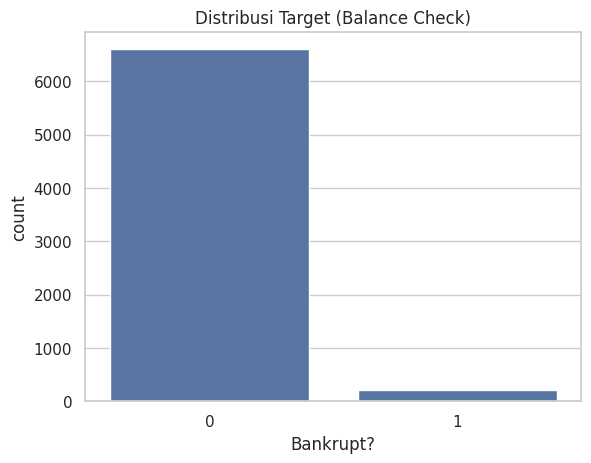

In [86]:
# Mengecek distribusi kelas
print(df['Bankrupt?'].value_counts())
print(df['Bankrupt?'].value_counts(normalize=True))

# Visualisasi
sns.countplot(data=df, x='Bankrupt?')
plt.title("Distribusi Target (Balance Check)")
plt.show()

In [87]:
#Random Oversampling
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(df.drop('Bankrupt?', axis=1), df['Bankrupt?'])

In [88]:
#Undersampling (mengurangi kelas mayoritas)
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(df.drop('Bankrupt?', axis=1), df['Bankrupt?'])

In [103]:
#SMOTE (Synthetic Minority Oversampling Technique)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [90]:
#Cek Missing Values
df.isnull().sum()
#jika ada mising value
df = df.dropna()
# atau di isi nilai
df.fillna(method='ffill', inplace=True)

In [91]:
#Cek Duplikat
df.duplicated().sum()

df = df.drop_duplicates()

In [92]:
# Menangani Outlier (contoh menggunakan ' ROA(C) before interest and depreciation before interest')
# Pastikan untuk mengganti ini dengan kolom yang sesuai dari dataset Anda.
column_to_check = ' ROA(C) before interest and depreciation before interest'

Q1 = df[column_to_check].quantile(0.25)
Q3 = df[column_to_check].quantile(0.75)
IQR = Q3 - Q1

df = df[(df[column_to_check] >= Q1 - 1.5*IQR) & (df[column_to_check] <= Q3 + 1.5*IQR)]

In [93]:
#Standarisasi Format Data
df.columns = df.columns.str.lower()

In [94]:
#Encoding data kategori → numerik
df_encoded = pd.get_dummies(df, drop_first=True)


In [95]:
#Scaling data numerik
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Select all columns except the target variable 'bankrupt?' for scaling
num_cols = df_encoded.columns.drop('bankrupt?')

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [96]:
# Split data
X = df_encoded.drop('bankrupt?', axis=1)
y = df_encoded['bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

###4. Modelling, Gunakan algoritma seperti Random Forest, Decision Tree, Artificial Neural Network. Manakah algoritma yang paling sesuai dengan dataset yang ada saat ini?


In [97]:
# MODEL DECISION TREE
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_res, y_train_res)

y_pred_dt = dt.predict(X_test)

print("\n=== DECISION TREE ===")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))



=== DECISION TREE ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1252
           1       0.20      0.50      0.29        34

    accuracy                           0.93      1286
   macro avg       0.59      0.72      0.63      1286
weighted avg       0.97      0.93      0.95      1286

Accuracy: 0.9346811819595645


In [98]:
# MODEL RANDOM FOREST
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))



=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1252
           1       0.39      0.38      0.39        34

    accuracy                           0.97      1286
   macro avg       0.69      0.68      0.69      1286
weighted avg       0.97      0.97      0.97      1286

Accuracy: 0.9681181959564541


In [99]:
# ARTIFICIAL NEURAL NETWORK (ANN)
ann = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                    solver='adam', max_iter=500, random_state=42)

ann.fit(X_train_res, y_train_res)

y_pred_ann = ann.predict(X_test)

print("\n=== ARTIFICIAL NEURAL NETWORK (ANN) ===")
print(classification_report(y_test, y_pred_ann))
print("Accuracy:", accuracy_score(y_test, y_pred_ann))



=== ARTIFICIAL NEURAL NETWORK (ANN) ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1252
           1       0.38      0.32      0.35        34

    accuracy                           0.97      1286
   macro avg       0.68      0.65      0.67      1286
weighted avg       0.97      0.97      0.97      1286

Accuracy: 0.9681181959564541


### 5. Evaluation, Lakukan evaluasi dari model yang anda sudah buat. Sajikan Confusion Matrix, Precision, Recall, f1-score dan sebagainya

=== Evaluation: Decision Tree ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1252
           1       0.20      0.50      0.29        34

    accuracy                           0.93      1286
   macro avg       0.59      0.72      0.63      1286
weighted avg       0.97      0.93      0.95      1286



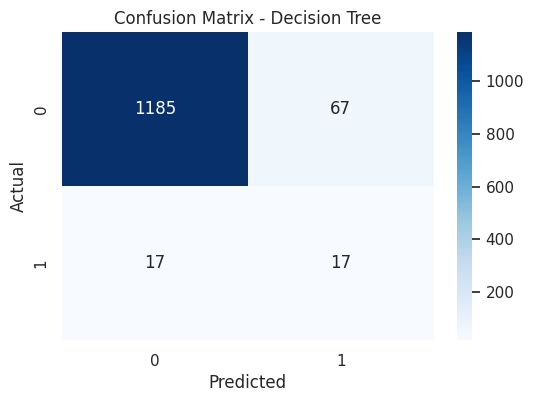

In [104]:
# EVALUASI DECISION TREE
print("=== Evaluation: Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Evaluation: Random Forest ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1252
           1       0.39      0.38      0.39        34

    accuracy                           0.97      1286
   macro avg       0.69      0.68      0.69      1286
weighted avg       0.97      0.97      0.97      1286



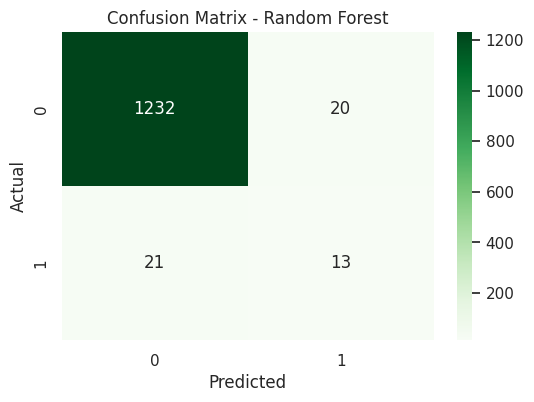

In [105]:
#EVALUASI RANDOM FOREST
print("=== Evaluation: Random Forest ===")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Evaluation: ANN (MLPClassifier) ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1252
           1       0.38      0.32      0.35        34

    accuracy                           0.97      1286
   macro avg       0.68      0.65      0.67      1286
weighted avg       0.97      0.97      0.97      1286



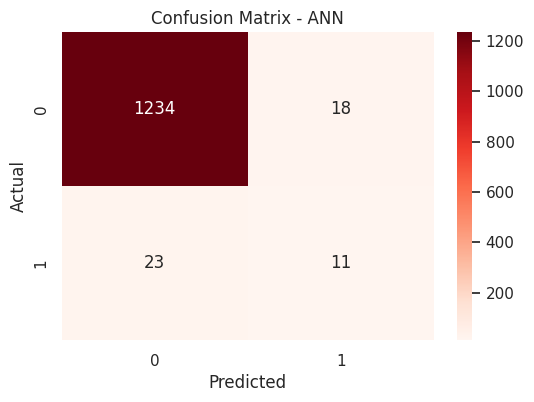

In [106]:
#EVALUASI ARTIFICIAL NEURAL NETWORK (ANN)
print("=== Evaluation: ANN (MLPClassifier) ===")
print(classification_report(y_test, y_pred_ann))

cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6,4))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
